In [1]:
import pandas as pd

In [2]:
from ast import literal_eval

# Data Retreival

In [3]:
path = "../data/resume_clean.csv"

resume_df = pd.read_csv(path)

resume_df.head()

,ID,Resume_str,Resume_html,Category,clean_description,degrees
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr administrator marketing associate hr admini...,"['Associate', 'High School Diploma']"
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist us hr operations summary versati...,"['Master', 'Bachelor']"
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr director summary over 20 years experience i...,"['Master', 'Bachelor']"
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist summary dedicated driven and dyn...,[]
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr manager skill highlights hr skills hr depar...,"['Associate', 'Bachelor']"


In [4]:
path = "../data/job_clean.csv"

job_df = pd.read_csv(path)

job_df.head()

,company_name,job_description,position_title,description_length,model_response,clean_description,Core Responsibilities,Required Skills,Educational Requirements,Experience Level,Preferred Qualifications,Compensation and Benefits,medical specialty,schedule,license/certification,degrees,required_skills_clean,skill_candidates
0,Google,minimum qualifications\nbachelors degree or eq...,Sales Specialist,2727,"{\n ""Core Responsibilities"": ""Responsible fo...",minimum qualifications bachelors degree or equ...,Responsible for expanding Google Workspace pro...,Bachelor's degree or equivalent experience. Ex...,Bachelor's degree or equivalent experience.,Experience managing enterprise SaaS accounts a...,Experience building strategic partnerships wit...,NaN,NaN,NaN,NaN,['Bachelor'],bachelor's degree or equivalent experience. ex...,"[""bachelor 's degree"", 'equivalent experience'..."
1,Apple,description\nas an asc you will be highly infl...,Apple Solutions Consultant,828,"{\n ""Core Responsibilities"": ""as an asc you ...",description as an asc you will be highly influ...,as an asc you will be highly influential in gr...,a passion to help people understand how apple ...,NaN,years preferred,NaN,NaN,NaN,NaN,NaN,[],a passion to help people understand how apple ...,"['apple product', 'livesexcellent communicatio..."
2,Netflix,its an amazing time to be joining netflix as w...,Licensing Coordinator - Consumer Products,3205,"{\n ""Core Responsibilities"": ""Help drive bus...",its an amazing time to be joining netflix as w...,Help drive business by supporting licensing ma...,2+ years experience in preferably outbound lic...,NaN,2+ years experience in preferably outbound lic...,Understanding of category manufacturing and sa...,NaN,NaN,NaN,NaN,[],2+ years experience in preferably outbound lic...,"['2 + year experience', 'preferably outbound l..."
3,Robert Half,description\n\nweb designers looking to expand...,Web Designer,2489,"{\n ""Core Responsibilities"": ""Designing webs...",description web designers looking to expand yo...,"Designing websites, wireframes, landing pages,...",2+ years experience in web design. Proficiency...,NaN,2+ years,UX/UI design experience. Knowledge of brand st...,NaN,NaN,NaN,NaN,[],2+ years experience in web design. proficiency...,"['2 + year experience', 'web design', 'strong ..."
4,TrackFive,at trackfive weve got big goals were on a miss...,Web Developer,3167,"{\n ""Core Responsibilities"": ""Build and layo...",at trackfive weve got big goals were on a miss...,"Build and layouts from provided PSD files, bui...","2+ years of experience with HTML and CSS/SASS,...",NaN,2+ years,NaN,Free health insurance for employees with no wa...,NaN,NaN,NaN,[],2+ years of experience with html and css sass ...,"['2 + year', 'programming php application', 'l..."


# EDA

### Top Resume Categories

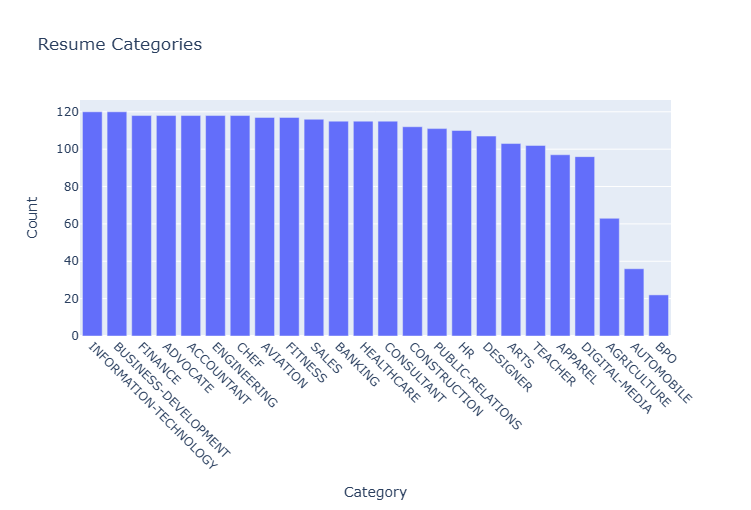

In [5]:
import plotly.express as px

category_counts = (
    resume_df["Category"]
    .value_counts()
    .reset_index()
)

category_counts.columns = ["Category", "Count"]

fig = px.bar(
    category_counts,
    x="Category",
    y="Count",
    title="Resume Categories",
    labels={
        "Category": "Category",
        "Count": "Count"
    }
)

fig.update_xaxes(tickangle=45)

fig.update_layout(
    width=1200,
    height=500
)

fig.show()

### Top Job Position Titles

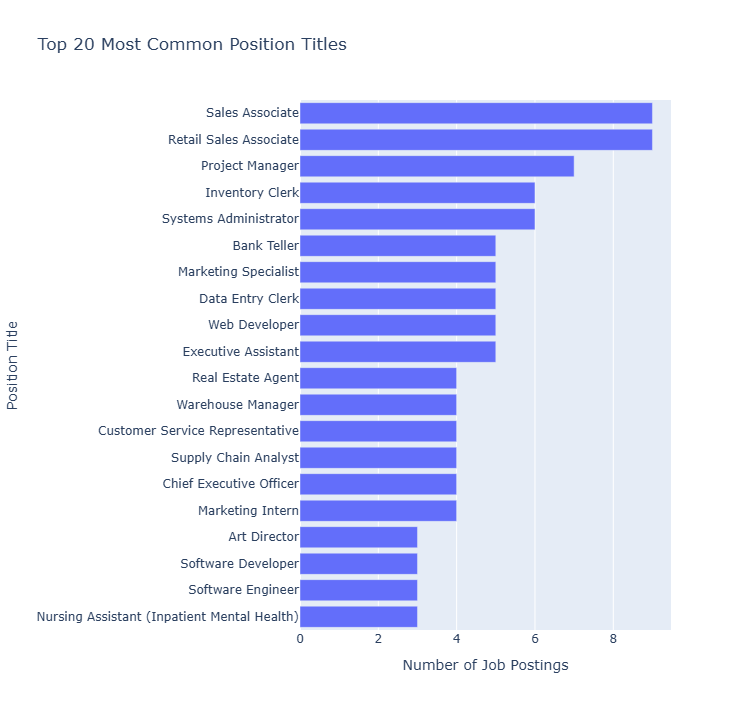

In [6]:
position_counts = (
    job_df["position_title"]
    .value_counts()
    .head(20)
    .sort_values()
    .reset_index()
)

position_counts.columns = ["Position Title", "Count"]

fig = px.bar(
    position_counts,
    x="Count",
    y="Position Title",
    orientation="h",
    title="Top 20 Most Common Position Titles",
    labels={
        "Position Title": "Position Title",
        "Count": "Number of Job Postings"
    }
)

fig.update_layout(
    width=1000,
    height=700
)

fig.show()

### Top Companies

In [7]:
job_df["company_name"].value_counts().head(20)

company_name
Google                                                                                  1
The Computer Merchant, Ltd                                                              1
Imagine     United States Remote                                                        1
YipitData                                                                               1
Usc Consulting Group Lp                                                                 1
NBA (National Basketball Association)                                                   1
Mackinnon Bruce International (Staffing Agency)   New Jersey, United States   Hybrid    1
Atlantic Group (Staffing Agency)  Monmouth County, NJ On-site                           1
Liberty Mutual Insurance  United States    Remote                                       1
LHH                                                                                     1
CoventBridge Group  Columbus, OH On-site                                               

### Length

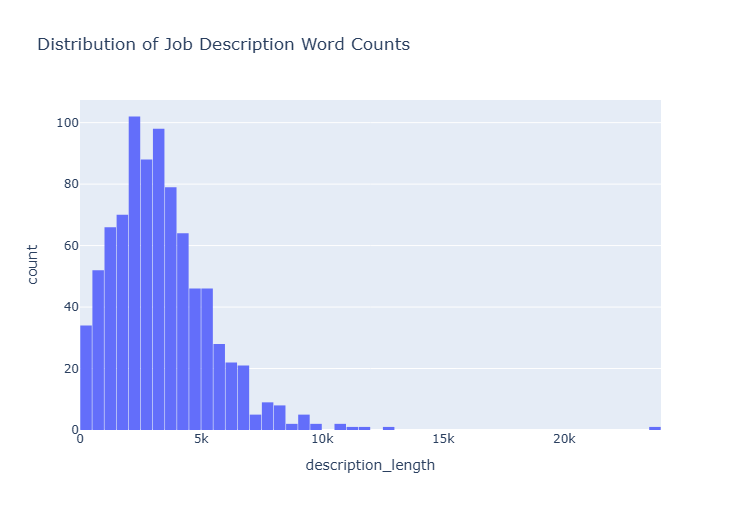

In [8]:
fig = px.histogram(
    job_df,
    x="description_length",
    nbins=50,
    title="Distribution of Job Description Word Counts",
    labels={
        "word_count": "Word Count",
        "count": "Number of Job Postings"
    }
)

fig.update_layout(
    width=900,
    height=500,
    bargap=0.05
)

fig.show()

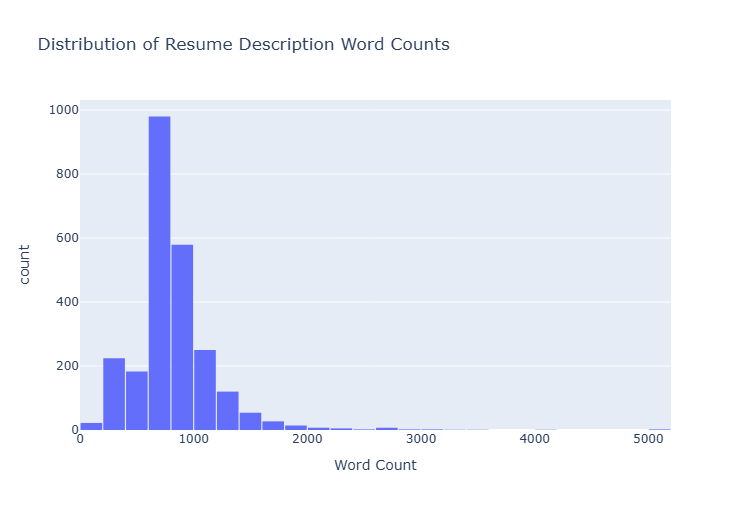

In [9]:
resume_df["word_count"] = resume_df["clean_description"].str.split().str.len()

fig = px.histogram(
    resume_df,
    x="word_count",
    nbins=50,
    title="Distribution of Resume Description Word Counts",
    labels={
        "word_count": "Word Count",
        "count": "Number of Resume"
    }
)

fig.update_layout(
    width=900,
    height=500,
    bargap=0.05
)

fig.show()

### Most Common Words

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english')

X = vectorizer.fit_transform(job_df["clean_description"])

word_counts = X.sum(axis=0).A1

vocab = vectorizer.get_feature_names_out()

common = (
    pd.DataFrame({
        "word": vocab,
        "count": word_counts
    })
    .sort_values("count", ascending=False)
)

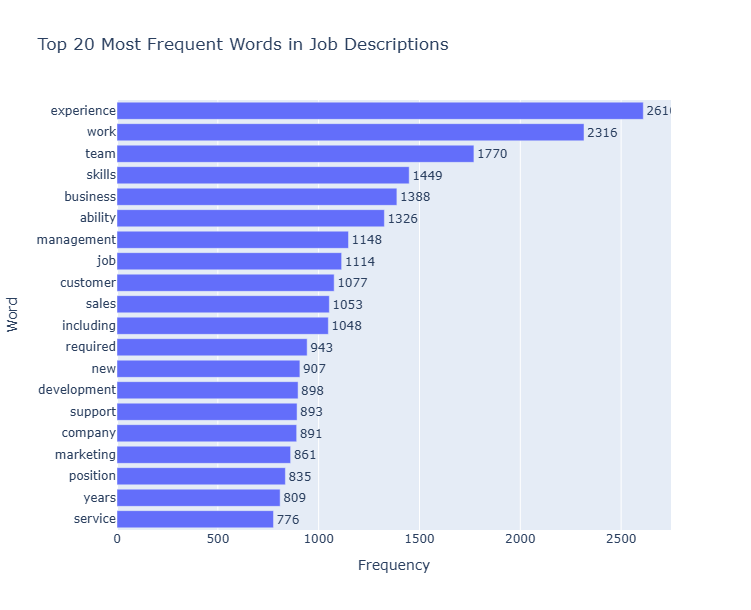

In [11]:
top_words = common.head(20).sort_values("count")

fig = px.bar(
    top_words,
    x="count",
    y="word",
    orientation="h",
    title="Top 20 Most Frequent Words in Job Descriptions",
    labels={
        "count": "Frequency",
        "word": "Word"
    },
    text="count"
)

fig.update_traces(textposition="outside")

fig.update_layout(
    width=900,
    height=600,
    yaxis=dict(categoryorder="total ascending")
)

fig.show()

In [12]:
vectorizer = CountVectorizer(stop_words='english')

X = vectorizer.fit_transform(resume_df["Resume_str"])

word_counts = X.sum(axis=0).A1

vocab = vectorizer.get_feature_names_out()

common = (
    pd.DataFrame({
        "word": vocab,
        "count": word_counts
    })
    .sort_values("count", ascending=False)
)

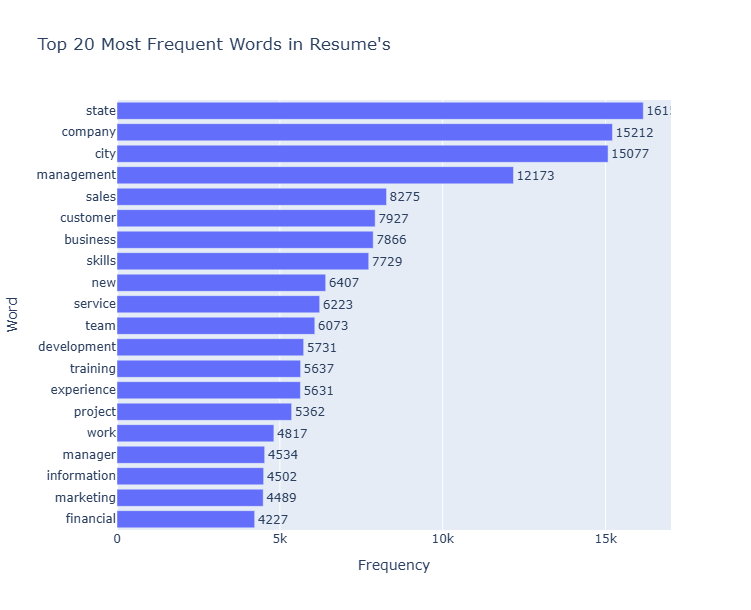

In [13]:
top_words = common.head(20).sort_values("count")

fig = px.bar(
    top_words,
    x="count",
    y="word",
    orientation="h",
    title="Top 20 Most Frequent Words in Resume's",
    labels={
        "count": "Frequency",
        "word": "Word"
    },
    text="count"
)

fig.update_traces(textposition="outside")

fig.update_layout(
    width=900,
    height=600,
    yaxis=dict(categoryorder="total ascending")
)

fig.show()

### Most Common Bigrams

In [14]:
eeo_headers = [
    "equal opportunity employer",
    "equal employment opportunity",
    "we are an equal opportunity employer",
    "all qualified applicants"
]

def remove_eeo(text):

    lower = text.lower()

    for phrase in eeo_headers:
        idx = lower.find(phrase)

        if idx != -1:
            return text[:idx]

    return text

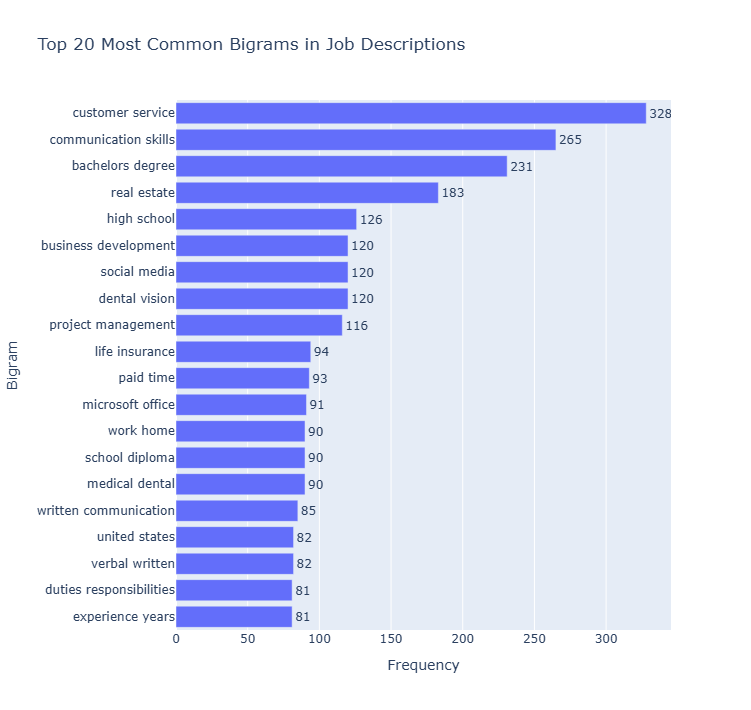

In [15]:
text = (
    job_df["clean_description"]
    .dropna()
    .astype(str)
    .apply(remove_eeo)
)

vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    min_df=2
)

X = vectorizer.fit_transform(text)

bigram_counts = X.sum(axis=0).A1
bigrams = vectorizer.get_feature_names_out()

remove_bigrams = {
    "years experience",
    "team members",
    "ability work",
    "skills ability",
    "job description",
    "minimum years",
    "related field",
    "experience working",
    "new york",
    "policies procedures",
    "best practices",
    "internal external",
    "work environment"
}

common_bigrams = (
    pd.DataFrame({
        "bigram": bigrams,
        "count": bigram_counts
    })
    .query("bigram not in @remove_bigrams")
    .sort_values("count", ascending=False)
    .head(20)
)

fig = px.bar(
    common_bigrams.sort_values("count"),
    x="count",
    y="bigram",
    orientation="h",
    text="count",
    title="Top 20 Most Common Bigrams in Job Descriptions",
    labels={
        "count": "Frequency",
        "bigram": "Bigram"
    }
)

fig.update_traces(textposition="outside")

fig.update_layout(
    width=900,
    height=700,
    yaxis=dict(categoryorder="total ascending")
)

fig.show()

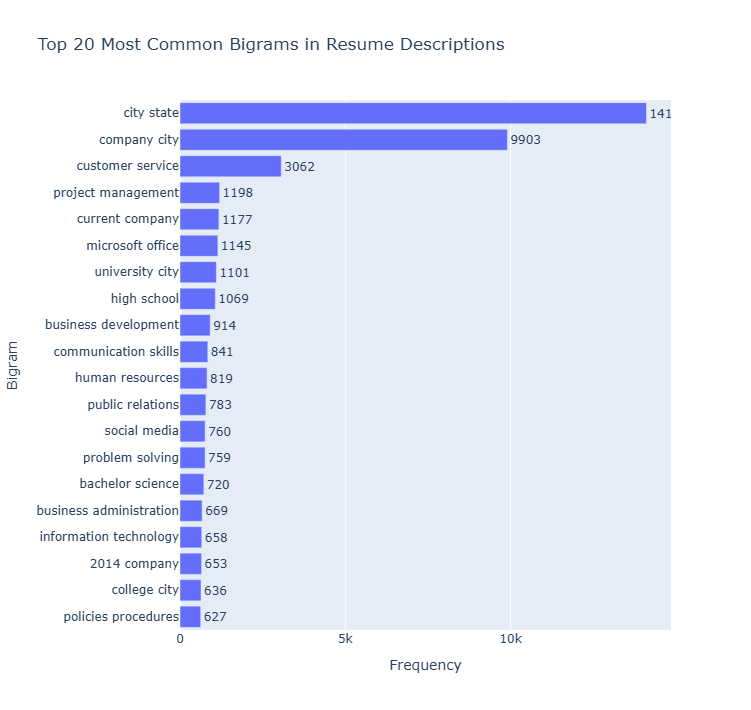

In [16]:
text = resume_df["clean_description"].dropna().astype(str)

# bigram
vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    min_df=2
)

X = vectorizer.fit_transform(text)

bigram_counts = X.sum(axis=0).A1
bigrams = vectorizer.get_feature_names_out()

common_bigrams = (
    pd.DataFrame({
        "bigram": bigrams,
        "count": bigram_counts
    })
    .sort_values("count", ascending=False)
    .head(20)
)

fig = px.bar(
    common_bigrams.sort_values("count"),
    x="count",
    y="bigram",
    orientation="h",
    text="count",
    title="Top 20 Most Common Bigrams in Resume Descriptions",
    labels={
        "count": "Frequency",
        "bigram": "Bigram"
    }
)

fig.update_traces(textposition="outside")

fig.update_layout(
    width=900,
    height=700,
    yaxis=dict(categoryorder="total ascending")
)

fig.show()

### Most Common Trigrams

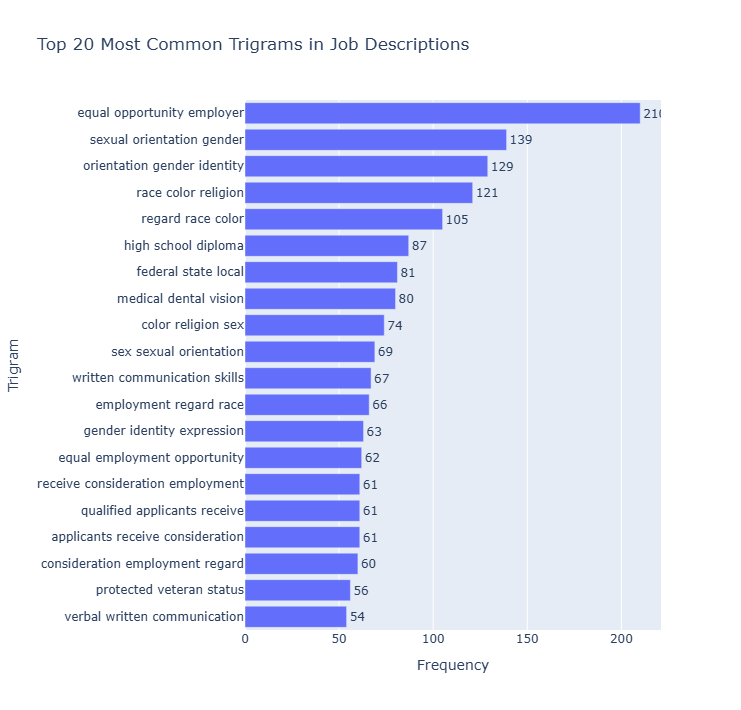

In [17]:
text = job_df["clean_description"].dropna().astype(str)

# bigram
vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(3, 3),
    min_df=3
)

X = vectorizer.fit_transform(text)

bigram_counts = X.sum(axis=0).A1
bigrams = vectorizer.get_feature_names_out()

common_bigrams = (
    pd.DataFrame({
        "bigram": bigrams,
        "count": bigram_counts
    })
    .sort_values("count", ascending=False)
    .head(20)
)

fig = px.bar(
    common_bigrams.sort_values("count"),
    x="count",
    y="bigram",
    orientation="h",
    text="count",
    title="Top 20 Most Common Trigrams in Job Descriptions",
    labels={
        "count": "Frequency",
        "bigram": "Trigram"
    }
)

fig.update_traces(textposition="outside")

fig.update_layout(
    width=900,
    height=700,
    yaxis=dict(categoryorder="total ascending")
)

fig.show()

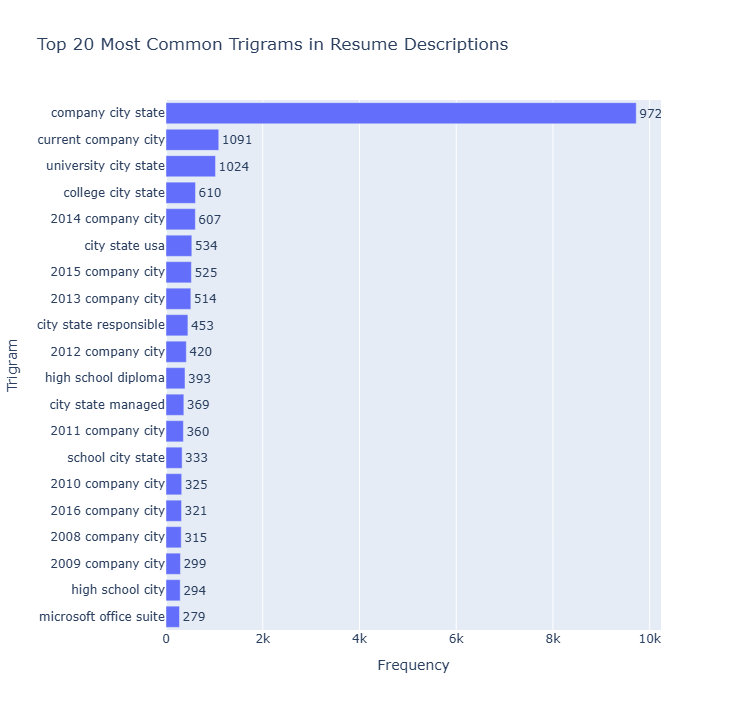

In [18]:
text = resume_df["clean_description"].dropna().astype(str)

# bigram
vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(3, 3),
    min_df=3
)

X = vectorizer.fit_transform(text)

bigram_counts = X.sum(axis=0).A1
bigrams = vectorizer.get_feature_names_out()

common_bigrams = (
    pd.DataFrame({
        "bigram": bigrams,
        "count": bigram_counts
    })
    .sort_values("count", ascending=False)
    .head(20)
)

fig = px.bar(
    common_bigrams.sort_values("count"),
    x="count",
    y="bigram",
    orientation="h",
    text="count",
    title="Top 20 Most Common Trigrams in Resume Descriptions",
    labels={
        "count": "Frequency",
        "bigram": "Trigram"
    }
)

fig.update_traces(textposition="outside")

fig.update_layout(
    width=900,
    height=700,
    yaxis=dict(categoryorder="total ascending")
)

fig.show()

## After Extraction

In [19]:
# skills = (
#     skills
#     .value_counts()
#     .reset_index(name="Count")
#     .sort_values("Count", ascending=True)
# )

### Most Common Skills

In [20]:
job_df["skill_candidates"] = job_df["skill_candidates"].apply(literal_eval)

skills = (
    job_df["skill_candidates"]
    .explode()
    .dropna()
    .astype(str)
    .str.lower()
    .str.strip()
)

skills = (
    skills
    .str.replace("’", "'", regex=False)
    .str.replace(r"\s*'\s*s\b", "'s", regex=True)
    .str.replace(r"\s*\+\s*", "+", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

remove = {
    "",
    "n a",
    "n/a",
    "required skill",
    "preferred skill",
    "qualification",
    "requirement",
    "experience",
    "candidate",
    "ability",
    "knowledge",
    "year experience",
    "fast pace environment",
    "work knowledge"
}

skills = skills[~skills.isin(remove)]

remove_pattern = (
    r"bachelor'?s?\s+degree"
    r"|high\s+school\s+diploma"
    r"|associate'?s?\s+degree"
    r"|master'?s?\s+degree"
    r"|related\s+field"
    r"|\b\d+\+?\s*years?(?:\s+experience)?\b"
    r"|driver'?s?\s+license"
    r"|customer\s+service\s+experience"
)

skills = skills[
    ~skills.str.contains(
        remove_pattern,
        case=False,
        regex=True,
        na=False
    )
]

skill_counts = (
    skills
    .value_counts()
    .head(15)
    .rename_axis("Skill")
    .reset_index(name="Count")
    .sort_values("Count", ascending=True)
)

skill_counts["Skill"] = skill_counts["Skill"].str.title()

fig = px.bar(
    skill_counts,
    x="Count",
    y="Skill",
    orientation="h",
    text="Count",
    title="Most Frequently Requested Skills",
    labels={
        "Count": "Number of Job Postings",
        "Skill": ""
    }
)

fig.update_layout(
    width=1000,
    height=650,
    xaxis_title="Number of Job Postings",
    yaxis_title="",
    yaxis=dict(categoryorder="total ascending"),
    showlegend=False
)

fig.show()

### Experience Requirement Distribution

In [21]:
# todo

### Education Requirements

In [22]:
## WIP

In [23]:
# fig = px.histogram(
#     job_df,
#     x="Educational Requirements",
#     nbins=50,
#     title="Distribution of Resume Description Word Counts",
#     labels={
#         "word_count": "Word Count",
#         "count": "Number of Resume"
#     }
# )

# fig.update_layout(
#     width=900,
#     height=500,
#     bargap=0.05
# )

# fig.show()

### Most Common Degree in Jobs

In [24]:
# have to find requirement vs preferred

In [25]:
# turn back to list
job_df["degrees"] = job_df["degrees"].apply(literal_eval)

degree_counts = (
    job_df["degrees"]
    .explode()                
    .dropna()
    .value_counts()
    .reset_index()
)

degree_counts.columns = ["Degree", "Count"]

fig = px.bar(
    degree_counts,
    x="Degree",
    y="Count",
    text="Count",
    title="Most Common Degrees in Jobs"
)

fig.update_layout(
    width=900,
    height=500,
    xaxis_title="Degree",
    yaxis_title="Number of Jobs"
)

fig.show()

### Most Common Degrees in Resumes

In [26]:
# turn back to list
resume_df["degrees"] = resume_df["degrees"].apply(literal_eval)

degree_counts = (
    resume_df["degrees"]
    .explode()                
    .dropna()
    .value_counts()
    .reset_index()
)

degree_counts.columns = ["Degree", "Count"]

fig = px.bar(
    degree_counts,
    x="Degree",
    y="Count",
    text="Count",
    title="Most Common Degrees in Resumes"
)

fig.update_layout(
    width=900,
    height=500,
    xaxis_title="Degree",
    yaxis_title="Number of Resumes"
)

fig.show()

### Similarity Analysis

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

resume_text = resume_df["Resume_str"].fillna("")
job_text = job_df["job_description"].fillna("")

all_text = pd.concat([resume_text, job_text], ignore_index=True)

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X = vectorizer.fit_transform(all_text)

# split
resume_vectors = X[:len(resume_df)]
job_vectors = X[len(resume_df):]

# sim
similarity = cosine_similarity(resume_vectors, job_vectors)

In [28]:
similarity.shape

(2484, 853)

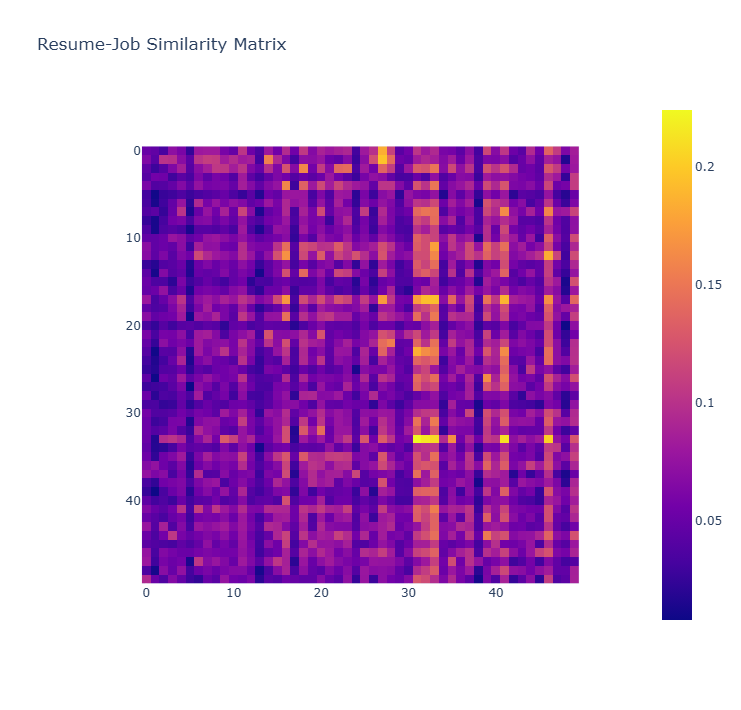

In [29]:
sample = similarity[:50, :50]

fig = px.imshow(
    sample,
    title="Resume-Job Similarity Matrix"
)

fig.update_layout(
    width=850,
    height=700
)

fig.show()

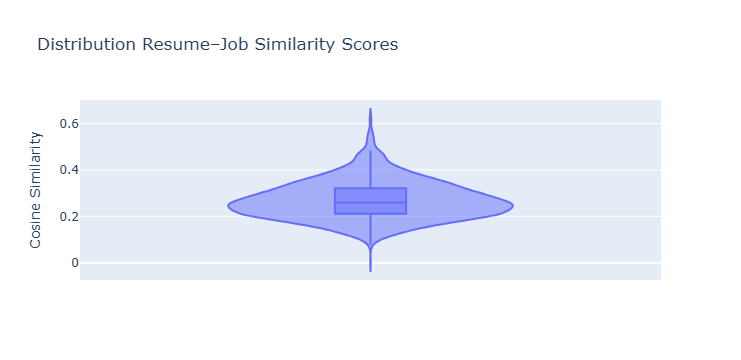

In [30]:
best_similarity = similarity.max(axis=1)

fig = px.violin(
    y=best_similarity,
    box=True,
    points=False,
    title="Distribution Resume–Job Similarity Scores",
    labels={"y": "Cosine Similarity"}
)

fig.show()